In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from functions import extract_names, human_format, format_axes

df = pd.read_csv("../data/raw/movies.csv", sep=',')

In [2]:
df.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [3]:
df.shape

(4803, 24)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   str    
 3   homepage              1712 non-null   str    
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   str    
 6   original_language     4803 non-null   str    
 7   original_title        4803 non-null   str    
 8   overview              4800 non-null   str    
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   str    
 11  production_countries  4803 non-null   str    
 12  release_date          4802 non-null   str    
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages      4803 non-n

In [5]:
df.isnull().sum()

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64

In [6]:
df = df.drop(columns=['homepage', 'id', 'keywords', 'original_title', 'overview', 'tagline', 'cast', 'crew'])
df.columns

Index(['index', 'budget', 'genres', 'original_language', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'title',
       'vote_average', 'vote_count', 'director'],
      dtype='str')

In [7]:
# converting the release date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

In [8]:
# checking if there is any duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
df['production_companies'].head(5)

0    [{"name": "Ingenious Film Partners", "id": 289...
1    [{"name": "Walt Disney Pictures", "id": 2}, {"...
2    [{"name": "Columbia Pictures", "id": 5}, {"nam...
3    [{"name": "Legendary Pictures", "id": 923}, {"...
4          [{"name": "Walt Disney Pictures", "id": 2}]
Name: production_companies, dtype: str

In [10]:
type(df['production_companies'].iloc[0])

str

In [11]:
# cleaning the production_companies, production_countries and spoken_languages columns
from functions import extract_names

df['production_companies'] = df['production_companies'].apply(extract_names)
df['production_countries'] = df['production_countries'].apply(extract_names)
df['spoken_languages'] = df['spoken_languages'].apply(extract_names)

In [12]:
df['production_companies'].head(5)

0    [Ingenious Film Partners, Twentieth Century Fo...
1    [Walt Disney Pictures, Jerry Bruckheimer Films...
2                     [Columbia Pictures, Danjaq, B24]
3    [Legendary Pictures, Warner Bros., DC Entertai...
4                               [Walt Disney Pictures]
Name: production_companies, dtype: object

In [13]:
df['production_countries'].head(5)

0    [United States of America, United Kingdom]
1                    [United States of America]
2    [United Kingdom, United States of America]
3                    [United States of America]
4                    [United States of America]
Name: production_countries, dtype: object

In [14]:
df['spoken_languages'].head(5)

0                                 [English, Español]
1                                          [English]
2    [Français, English, Español, Italiano, Deutsch]
3                                          [English]
4                                          [English]
Name: spoken_languages, dtype: object

In [ ]:
df.to_csv("../data/clean/df_movies_francisca.csv", index=False)

## EDA

##### Director effect
Hypothesis 2: The choice of director significantly influences the production budget of a film.

In [72]:
nolan_median = df[df['director'] == 'Christopher Nolan']['budget'].median()
print(f"Christopher Nolan's average budget: {nolan_mean:,.0f}")

Christopher Nolan's average budget: 155,000,000


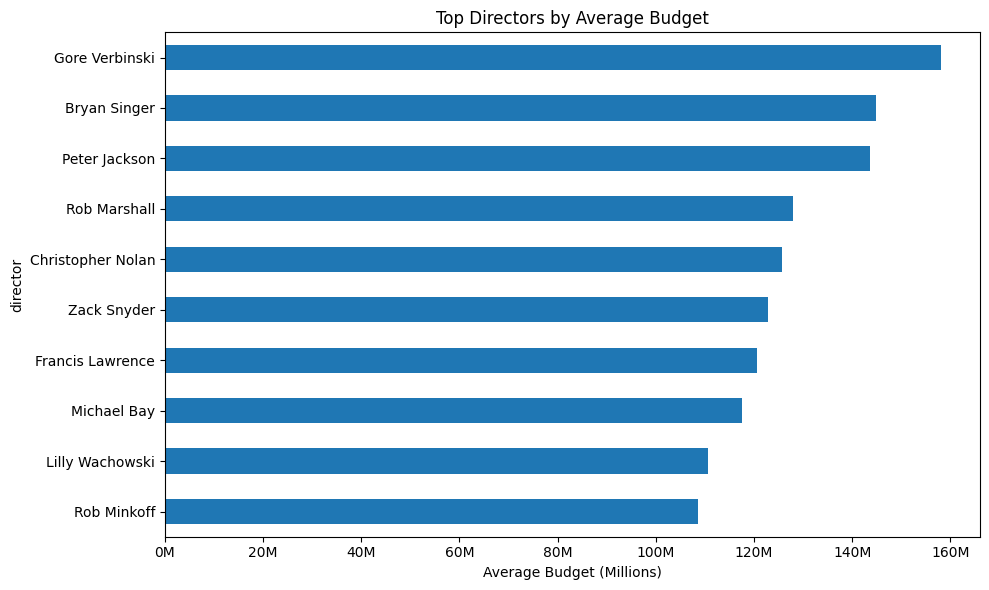

In [75]:
# Count number of movies per director
director_counts = df['director'].value_counts()

# Keep directors with at least 5 movies
top_directors = director_counts[director_counts >= 5].index

# Filter dataset
df_filtered = df[df['director'].isin(top_directors)]

director_budget = (
    df_filtered
    .groupby('director')['budget']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

ax = director_budget.sort_values().plot(kind='barh', figsize=(10,6))

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.xlabel('Average Budget (Millions)')
plt.title('Top Directors by Average Budget')

plt.tight_layout()
plt.show()

##### Runtime vs Ratings
Hypothesis 3: Films with longer runtimes tend to receive lower popularity or audience approval compared to shorter films.

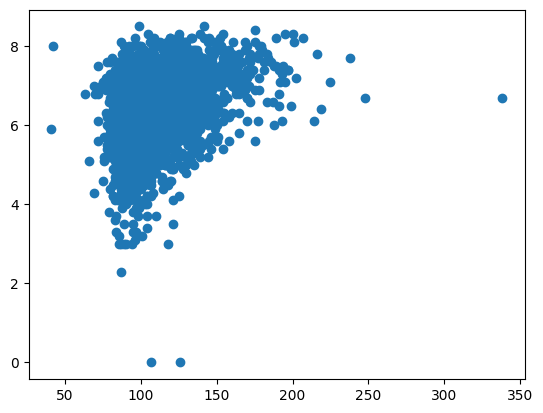

In [76]:
plt.scatter(df['runtime'], df['vote_average'])

##### Francisca Notebook

## Hypothesis 1
Hypothesis 1:  Films with larger production budgets generate higher box office revenue compared to films with smaller budgets.

Null hypothesis (H₀):
There is no relationship between budget and revenue

Alternative hypothesis (H₁):
There is a positive relationship between budget and revenue

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.ticker import FuncFormatter
from functions import human_format, format_axes

In [17]:
df.head()

,index,budget,genres,original_language,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,title,vote_average,vote_count,director
0,0,237000000,Action Adventure Fantasy Science Fiction,en,150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",Released,Avatar,7.2,11800,James Cameron
1,1,300000000,Adventure Fantasy Action,en,139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],2007-05-19,961000000,169.0,[English],Released,Pirates of the Caribbean: At World's End,6.9,4500,Gore Verbinski
2,2,245000000,Action Adventure Crime,en,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",2015-10-26,880674609,148.0,"[Français, English, Español, Italiano, Deutsch]",Released,Spectre,6.3,4466,Sam Mendes
3,3,250000000,Action Crime Drama Thriller,en,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],2012-07-16,1084939099,165.0,[English],Released,The Dark Knight Rises,7.6,9106,Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,en,43.926995,[Walt Disney Pictures],[United States of America],2012-03-07,284139100,132.0,[English],Released,John Carter,6.1,2124,Andrew Stanton


In [18]:
df.describe()

,index,budget,popularity,release_date,revenue,runtime,vote_average,vote_count
count,4803.000000,4.803000e+03,4803.000000,4802,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2401.000000,2.904504e+07,21.492301,2002-12-27 23:45:54.352353,8.226064e+07,106.875859,6.092172,690.217989
min,0.000000,0.000000e+00,0.000000,1916-09-04 00:00:00,0.000000e+00,0.000000,0.000000,0.000000
25%,1200.500000,7.900000e+05,4.668070,1999-07-14 00:00:00,0.000000e+00,94.000000,5.600000,54.000000
50%,2401.000000,1.500000e+07,12.921594,2005-10-03 00:00:00,1.917000e+07,103.000000,6.200000,235.000000
75%,3601.500000,4.000000e+07,28.313505,2011-02-16 00:00:00,9.291719e+07,118.000000,6.800000,737.000000
max,4802.000000,3.800000e+08,875.581305,2017-02-03 00:00:00,2.787965e+09,338.000000,10.000000,13752.000000
std,1386.651002,4.072239e+07,31.816650,NaN,1.628571e+08,22.611935,1.194612,1234.585891


In [19]:
# Definig a function to make the values more readable
from matplotlib.ticker import FuncFormatter

from functions import human_format, format_axes

In [20]:
# removing those films that have a budget and revenue of 0.00
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

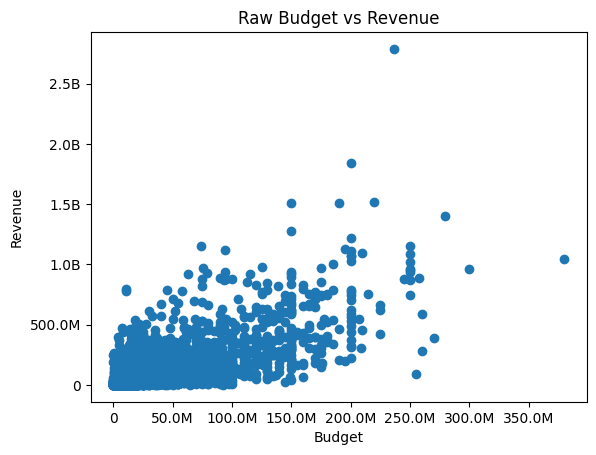

In [21]:
fig, ax = plt.subplots()

ax.scatter(df['budget'], df['revenue'])

format_axes(ax)

ax.set_xlabel('Budget')
ax.set_ylabel('Revenue')
ax.set_title('Raw Budget vs Revenue')

plt.show()

In [22]:
df['log_budget'] = np.log(df['budget'])
df['log_revenue'] = np.log(df['revenue'])

A logarithmic transformation was applied to budget and revenue to reduce skewness and better capture the proportional relationship between the variables.

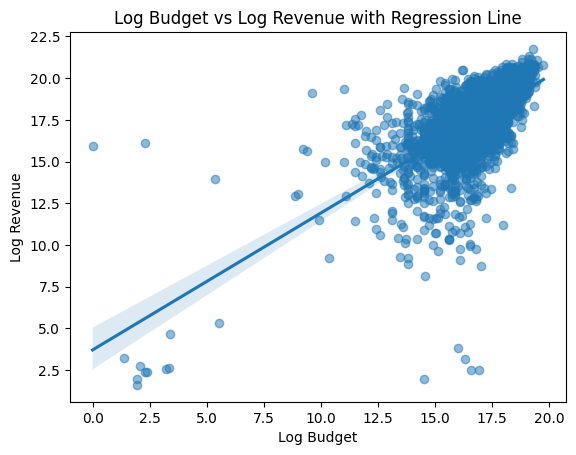

In [66]:
plt.figure()
sns.regplot(x=df['log_budget'], y=df['log_revenue'], scatter_kws={'alpha':0.5})
plt.xlabel('Log Budget')
plt.ylabel('Log Revenue')
plt.title('Log Budget vs Log Revenue with Regression Line')
plt.show()

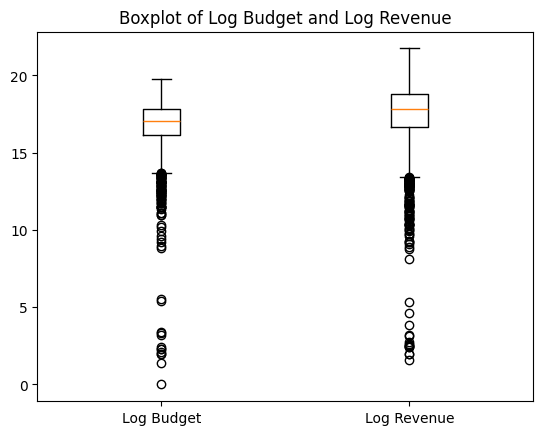

In [24]:
# Detecting outliers
fig, ax = plt.subplots()

ax.boxplot([df['log_budget'], df['log_revenue']])

ax.set_xticklabels(['Log Budget', 'Log Revenue'])
ax.set_title('Boxplot of Log Budget and Log Revenue')

plt.show()

The raw data shows a highly skewed distribution with significant clustering and outliers, making the relationship difficult to interpret. After applying a logarithmic transformation, the data becomes more evenly distributed and reveals a clear positive relationship between budget and revenue.

In [25]:
# Correlation with outliers
correlation = df['log_budget'].corr(df['log_revenue'])
print(correlation) #moderate

0.657083635641743


In [26]:
# Correlation without outliers

q_low = df['log_revenue'].quantile(0.01)
q_high = df['log_revenue'].quantile(0.99)

df_no_outliers = df[(df['log_revenue'] > q_low) & (df['log_revenue'] < q_high)]

df_no_outliers['log_budget'].corr(df_no_outliers['log_revenue'])

np.float64(0.6006073799295873)

Outliers were examined using boxplots and visual inspection. While some extreme values were present, they represent real high-performing films and were retained. The results remained consistent after removing extreme values, indicating that the relationship is robust.

In [27]:
# Statistical test
corr, p_value = pearsonr(df['log_budget'], df['log_revenue'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.6570836356417425
P-value: 0.0


A Pearson correlation test was conducted to examine the relationship between film budget and revenue. The results show a moderately strong positive correlation (r = 0.66). The relationship remained consistent after removing outliers (r = 0.60), indicating robustness. The p-value was below 0.00, allowing us to reject the null hypothesis. Therefore, there is sufficient evidence to conclude that films with larger production budgets tend to generate higher box office revenue.

## Into the machine learning

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor


In [28]:
df['num_companies'] = df['production_companies'].apply(len)
df[['production_companies', 'num_companies']].head()

,production_companies,num_companies
0,"[Ingenious Film Partners, Twentieth Century Fo...",4
1,"[Walt Disney Pictures, Jerry Bruckheimer Films...",3
2,"[Columbia Pictures, Danjaq, B24]",3
3,"[Legendary Pictures, Warner Bros., DC Entertai...",4
4,[Walt Disney Pictures],1


In [29]:
df['release_year'] = df['release_date'].dt.year

In [30]:
features = [
    'log_budget',
    'vote_average',
    'vote_count',
    'runtime',
    'release_year',
    'num_companies'
] 

target = 'log_revenue'

In [31]:
X = df[features]
y = df[target]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##### Scaling

In [33]:
scaler = MinMaxScaler()

scaler.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [34]:
X_train_norm = scaler.transform(X_train)

X_test_norm = scaler.transform(X_test)

In [35]:
X_train.head()

,log_budget,vote_average,vote_count,runtime,release_year,num_companies
2823,16.300417,6.2,497,107.0,2008,1
2666,16.523561,7.6,2827,120.0,2008,4
4586,17.370859,5.8,923,99.0,2008,6
372,18.337299,6.8,579,126.0,2001,6
2743,16.380460,7.3,2060,113.0,2004,5


In [36]:
X_train_norm

array([[0.82248519, 0.74698795, 0.0361402 , 0.22222222, 0.92      ,
        0.03846154],
       [0.83479113, 0.91566265, 0.2055701 , 0.26599327, 0.92      ,
        0.15384615],
       [0.88151797, 0.69879518, 0.06711751, 0.1952862 , 0.92      ,
        0.23076923],
       ...,
       [0.88151797, 0.75903614, 0.01141652, 0.38383838, 0.81      ,
        0.07692308],
       [0.91974371, 0.77108434, 0.13183537, 0.21212121, 0.92      ,
        0.15384615],
       [0.6349157 , 0.93975904, 0.12420012, 0.16835017, 0.59      ,
        0.15384615]], shape=(2583, 6))

In [37]:
X_train_norm = pd.DataFrame(X_train_norm, columns=X_train.columns, index=X_train.index )
X_train_norm.head()

,log_budget,vote_average,vote_count,runtime,release_year,num_companies
2823,0.822485,0.746988,0.036140,0.222222,0.92,0.038462
2666,0.834791,0.915663,0.205570,0.265993,0.92,0.153846
4586,0.881518,0.698795,0.067118,0.195286,0.92,0.230769
372,0.934815,0.819277,0.042103,0.286195,0.85,0.230769
2743,0.826899,0.879518,0.149796,0.242424,0.88,0.192308


In [38]:
X_test_norm = pd.DataFrame(X_test_norm, columns=X_test.columns, index=X_test.index)
X_test_norm.head()

,log_budget,vote_average,vote_count,runtime,release_year,num_companies
460,0.927108,0.638554,0.036213,0.205387,0.95,0.269231
2473,0.834791,0.807229,0.074171,0.185185,0.92,0.230769
302,0.927108,0.783133,0.051120,0.188552,0.94,0.153846
4221,0.707808,0.879518,0.011635,0.235690,0.29,0.038462
1785,0.855912,0.843373,0.019052,0.329966,0.87,0.153846


##### Feature Selection

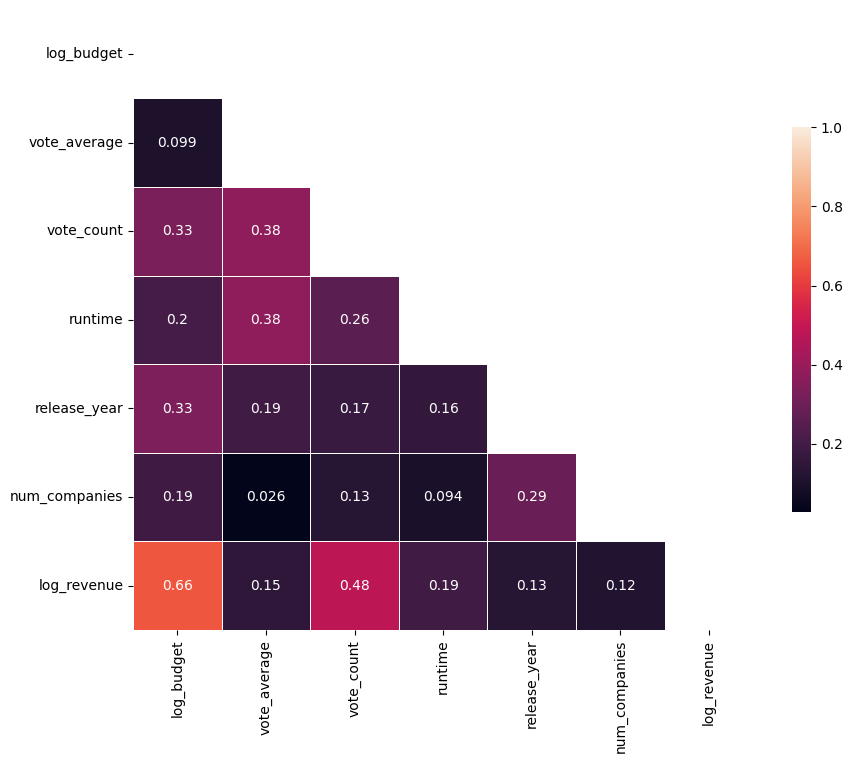

In [39]:
model_df = df[features + [target]]

corr=np.abs(model_df.corr())

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

plt.show()

As we can sse, budget and vote count clearly have a stronger relation with revenue, so let's test our models with all features first, and the with just these two.

##### Train Test Split - two strong features

In [40]:
features = ['log_budget', 'vote_count',]

target = 'log_revenue'

X_strong = df[features]
y_strong = df[target]

In [41]:
X_strong_train, X_strong_test, y_strong_train, y_strong_test = train_test_split(
    X_strong, y_strong, test_size=0.2, random_state=42
)

In [42]:
scaler = MinMaxScaler()

scaler.fit(X_strong_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [43]:
X_strong_train_norm = scaler.transform(X_strong_train)

X_strong_test_norm = scaler.transform(X_strong_test)

In [44]:
X_strong_train_norm = pd.DataFrame(X_strong_train_norm, columns=X_strong_train.columns, index=X_strong_train.index )
X_strong_train_norm.head()

,log_budget,vote_count
2823,0.822485,0.036140
2666,0.834791,0.205570
4586,0.881518,0.067118
372,0.934815,0.042103
2743,0.826899,0.149796


In [45]:
X_strong_test_norm = pd.DataFrame(X_strong_test_norm, columns=X_strong_test.columns, index=X_strong_test.index)
X_strong_test_norm.head()

,log_budget,vote_count
460,0.927108,0.036213
2473,0.834791,0.074171
302,0.927108,0.051120
4221,0.707808,0.011635
1785,0.855912,0.019052


##### KNN Regressor - modeling (all features)

In [46]:
for k in range(3, 15):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    print(k, knn.score(X_test, y_test))

y_pred_knn = knn.predict(X_test)

3 0.35414426152554646
4 0.40143229250045454
5 0.4382792053118404
6 0.45488596354712196
7 0.455927287188859
8 0.46321582223431745
9 0.4663836313250864
10 0.48294044832686756
11 0.48529320200238346
12 0.4839209238444738
13 0.48307264111647463
14 0.48698436410812085


In [47]:
knn.fit(X_train_norm, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",14
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [48]:
print(f"The R2 of the model on the TEST set is: {knn.score(X_test_norm, y_test): .2f}")

The R2 of the model on the TEST set is:  0.53


Hyperparameter tuning was performed for the K-Nearest Neighbors model by testing different values of k. Performance improved as k increased, stabilizing around k = 10–14. The final model achieved an R² score of 0.53, outperforming both Linear Regression and Decision Tree models. This indicates that similarity-based methods better capture the relationship between features and movie revenue.

##### KNN Regressor - modeling (strong features)

In [49]:
for k in range(3, 15):
    knn_strong = KNeighborsRegressor(n_neighbors=k)
    knn_strong.fit(X_train, y_train)
    print(k, knn_strong.score(X_test, y_test))

3 0.35414426152554646
4 0.40143229250045454
5 0.4382792053118404
6 0.45488596354712196
7 0.455927287188859
8 0.46321582223431745
9 0.4663836313250864
10 0.48294044832686756
11 0.48529320200238346
12 0.4839209238444738
13 0.48307264111647463
14 0.48698436410812085


In [50]:
knn_strong.fit(X_strong_train_norm, y_strong_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",14
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [51]:
print(f"The R2 of the model on the TEST set is: {knn_strong.score(X_strong_test_norm, y_strong_test): .2f}")

The R2 of the model on the TEST set is:  0.51


KNN model performs better with all the features.

##### Linear Model (all features)

In [52]:
lin_reg = LinearRegression()

lin_reg.fit(X_train_norm, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
y_pred_test = lin_reg.predict(X_test_norm)

print(f"MAE {mean_absolute_error(y_pred_test, y_test): .2f}") 
print(f"MSE {mean_squared_error(y_pred_test, y_test): .2f}")
print(f"RMSE, {root_mean_squared_error(y_pred_test, y_test): .2f}") 
print(f"R2 score, {lin_reg.score(X_test_norm, y_test): .2f}")

MAE  0.95
MSE  2.29
RMSE,  1.51
R2 score,  0.45


##### Linear Regression (strong feautres)

In [54]:
lin_reg_strong = LinearRegression()

lin_reg_strong.fit(X_strong_train_norm, y_strong_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
y_pred_test = lin_reg_strong.predict(X_strong_test_norm)

print(f"MAE {mean_absolute_error(y_pred_test, y_strong_test): .2f}") 
print(f"MSE {mean_squared_error(y_pred_test, y_strong_test): .2f}")
print(f"RMSE, {root_mean_squared_error(y_pred_test, y_strong_test): .2f}") 
print(f"R2 score, {lin_reg_strong.score(X_strong_test_norm, y_strong_test): .2f}")

MAE  0.98
MSE  2.38
RMSE,  1.54
R2 score,  0.43


Linear Model performs better with all the features

##### Decision Tree

In [56]:
DecisionTreeRegressor(max_depth=5)

tree = DecisionTreeRegressor(random_state=0)

In [57]:
tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

In [58]:
y_pred_tree = tree.predict(X_test)

In [59]:
rmse_tree = mean_squared_error(y_test, y_pred_tree) ** 0.5
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree RMSE:", rmse_tree)
print("Decision Tree R²:", r2_tree)

Decision Tree RMSE: 1.6299537303723235
Decision Tree R²: 0.36661397801035667


Among the tested models, K-Nearest Neighbors achieved the highest performance (R² = 0.53), outperforming both Linear Regression (R² = 0.45) and Decision Tree (R² = 0.37). This suggests that the relationship between features and revenue is not purely linear and is better captured by similarity-based methods.

##### Comparing models

In [60]:
results = {
    "Model": ["Linear Regression", "Decision Tree", "KNN"],
    "R2": [0.45, 0.37, 0.53]
}

import pandas as pd
pd.DataFrame(results)

,Model,R2
0,Linear Regression,0.45
1,Decision Tree,0.37
2,KNN,0.53


Select your best model in terms of the performance in the test set and analyze it's predictions

##### Visualizing the KNN (best model)

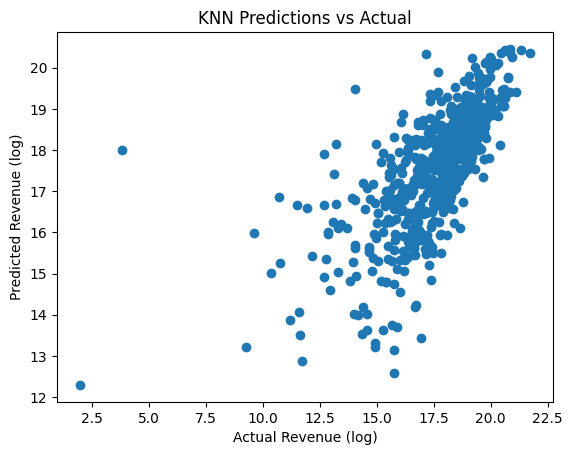

In [61]:
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual Revenue (log)")
plt.ylabel("Predicted Revenue (log)")
plt.title("KNN Predictions vs Actual")
plt.show()

Among the evaluated models, the K-Nearest Neighbors (KNN) model achieved the best performance, with an R² score of 0.53 on the test set. To analyze its predictions, a scatter plot of predicted versus actual revenue was examined. The plot shows a clear positive relationship, indicating that the model effectively captures the general trend in the data. However, there is noticeable dispersion around the diagonal line, suggesting prediction errors. The model performs better for mid-range revenue values, while predictions for very low and very high revenues are less accurate. Overall, the model demonstrates moderate predictive performance, capturing general patterns but lacking precision in individual predictions.

##### Final conclusion

This part of the project aimed to investigate the relationship between a film’s production budget and its box office revenue, as well as to build predictive models to estimate revenue based on available features. The initial hypothesis stated that films with larger production budgets generate higher box office revenue compared to films with smaller budgets.

The exploratory analysis and correlation results supported this hypothesis, revealing a clear positive relationship between budget and revenue. This relationship was further confirmed through the machine learning models, particularly the K-Nearest Neighbors, where budget showed a meaningful contribution to revenue prediction.

Among the models tested, the K-Nearest Neighbors (KNN) model achieved the best performance, with an R² score of 0.53. Analysis of its predictions showed that the model captures the overall trend between features and revenue, although it lacks precision for extreme values. This indicates that while the selected features are useful, they do not fully explain the variability in movie revenue.

Therefore, while the hypothesis is supported, the results also suggest that budget alone is not sufficient to accurately predict a film’s success. Other factors such as marketing investment, cast popularity, genre, release timing, and audience reception likely play a significant role in determining box office performance. These variables were not fully captured in the dataset and may explain the remaining unexplained variance in the models.

In conclusion, higher budgets are generally associated with higher revenues, but movie success is influenced by a combination of multiple factors, making it a complex phenomenon that cannot be explained by budget alone.

##### Creating the csv files for the presentaion

In [62]:
df_sample = df[['log_budget', 'log_revenue']].sample(n=300, random_state=42)
df_sample.to_csv("log_budget_sample.csv", index=False)

In [63]:
knn_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_knn
})

# Optional: sample to reduce size
knn_sample = knn_results.sample(n=300, random_state=42)

knn_sample.to_csv("knn_predictions_sample.csv", index=False)

In [81]:
director_budget_df = director_budget.reset_index(name='average_budget')

director_budget_df['average_budget_millions'] = director_budget_df['average_budget'] / 1e6

director_budget_df.to_csv("top_directors_budget.csv", index=False)